In [2]:
import numpy as np
from scipy.stats import poisson

def xlzd_statistic(B):
    return 1.64*np.sqrt(B)


def poisson_stat(B, ntrials=2000):
    observed_counts = np.random.poisson(B, ntrials)
    upper_limits = []
    for i in range(ntrials):
        if i % 1000 == 0:
            print("Trial {}".format(i))
        S = np.linspace(0.,B*3.,300)
        s = 0.
        for j in range(len(S)):
            s = S[j]
            mu = s + B
            # Get the value of the poisson CDF at observed_counts[i]
            val = poisson.cdf(observed_counts[i], mu)
            if val <= 0.1:
                break
    upper_limits.append(s)
    
    return np.array(upper_limits)
    
    

In [3]:
B = 1.

XLZD = xlzd_statistic(B)
POISSON_UL = poisson_stat(B)

print("XLZD upper limit for B={}: {:.2f}".format(B, XLZD))
print("Poisson upper limit for B={}: {:.2f} ± {:.2f}".format(B, np.median(POISSON_UL), np.std(POISSON_UL)))





Trial 0
Trial 1000
XLZD upper limit for B=1.0: 1.64
Poisson upper limit for B=1.0: 1.30 ± 0.00


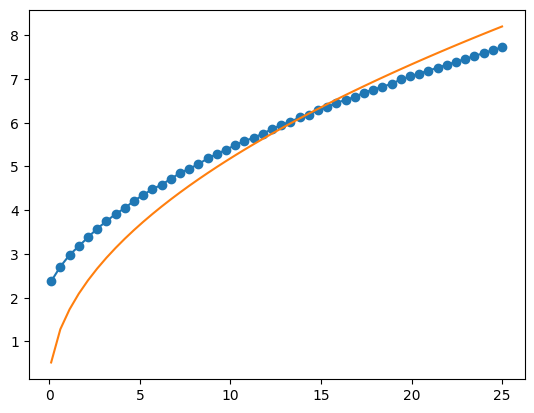

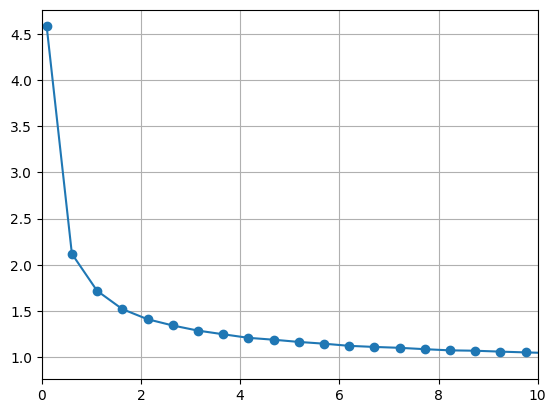

In [4]:
from scipy.special import gammaincc


# print(gammaincc(1., 2.))

def poisson_ul_gammaincc(b, cl=0.9):
    ul = np.zeros(len(b))
    for i,thisb in enumerate(b):
        s = np.linspace(0., 10., 300)
        # print(s.shape)
        # print(s[0])
        thiss = 0.
        for j in range(len(s)):
            mu = s[j] + thisb
            # print(mu)
            thiss = s[j]
            val = gammaincc(thisb+1, mu)
            # print(val)
            if val <= 1. - cl:
                break
        ul[i] = thiss
        
    return ul
    
    
B_values = np.linspace(0.1, 25., 50)


UL_gammaincc = poisson_ul_gammaincc(B_values)

import matplotlib.pyplot as plt

plt.plot(B_values, UL_gammaincc, '-o', label='Poisson UL (gammaincc)')
plt.plot(B_values, xlzd_statistic(B_values), '-', label='XLZD UL')

plt.figure(2)
plt.plot(B_values, (UL_gammaincc / xlzd_statistic(B_values)), '-o')

plt.xlim(0.,10.)
plt.grid()

`gammaincc` is the regularized incomplete gamma function:
\begin{equation}
    Q(s,x) = \frac{\Gamma (s,x)}{\Gamma(s)}
\end{equation}

The sensitivity function we want is the following:
\begin{equation}
    p_{sens} = \frac{\Gamma (b+1, s+b)} {\Gamma (b+1)}
\end{equation}

# PLR sensitivity, counting experiment (Feldman Cousins)


The Poisson distribution for some fixed background $b$ and signal $s$ is:
\begin{equation}
P(x,s,b) = \frac{e^{-(s+b)} (s+b)^k}{k!}
\end{equation}

The profile likelihood ratio is given by:
\begin{equation}
\lambda(s) = -2 \log( \frac{P(x,s,b)}{P(x,s_{best},b)} ) = -2 \left[ \log{P(x,s,b)} - \log{P(x,s_{best},b)} \right]
\end{equation}

The best-fit signal is always such that the observed counts equals $s+b$, so $s_{best} = k-b$ with $k$ being the observed number of counts.

This means that the profile likelihood ratio simplifies to 

\begin{equation}
\lambda = 2 \left[ s + b - k - k\left( \log{(s+b)} - \log{k} \right) \right]
\end{equation}

The "critical lambda" curve can then be constructed as a function of $s$ by computing the 90th percentile of the distribution of values of $\lambda$ for fixed $s$.




In [15]:
def plr_stat(s,b,k):
    if not np.isscalar(k):
        output = np.zeros(len(k))
        mask = k > 0.
        output[mask] = 2 * (s + b - k[mask] + k[mask] * np.log(k[mask] / (s + b)))
        output[~mask] = 2 * (s + b)
        return output
    else:
        if k > 0.:
            return 2 * (s + b - k + k * np.log(k / (s + b)))
        else:
            return 2 * (s + b)
    
    

# k = range(20)
# lambdas = plr_stat(0., 3., np.array(k))

# plt.plot(k, lambdas, '-o')
# plt.xlabel('k (observed counts)')
# plt.ylabel('PLR statistic $\\lambda$ for s=0, b=3')

In [8]:
def compute_critical_plr(b, signal_cts = np.linspace(0.,30.,300), cl=0.9, ntrials=100000):
    critical_values = []
    for s in signal_cts:
        observed_counts = np.random.poisson(s + b, ntrials)
        plr_values = plr_stat(s, b, observed_counts)
        plr_critical = np.percentile(plr_values, cl*100)
        critical_values.append(plr_critical)
    return np.array(critical_values)




(0.0, 10.0)

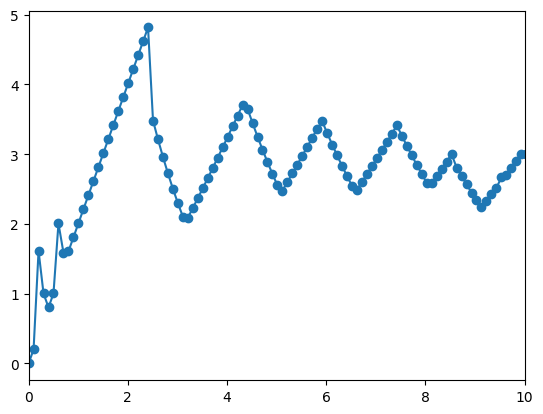

In [10]:
signal_cts = np.linspace(0.,30.,300)
critical_curve_0 = compute_critical_plr(0., signal_cts)

plt.figure(5)
plt.plot(signal_cts, critical_curve_0, '-o')
plt.xlim(0.,10.)


Computing critical PLR curve for b=0.00, elapsed time: 0.00 seconds
Computing critical PLR curve for b=5.00, elapsed time: 30.73 seconds
Computing critical PLR curve for b=10.00, elapsed time: 60.80 seconds
Computing critical PLR curve for b=15.00, elapsed time: 92.20 seconds
Computing critical PLR curve for b=20.00, elapsed time: 120.33 seconds
Computing critical PLR curve for b=25.00, elapsed time: 146.82 seconds
Computing critical PLR curve for b=30.00, elapsed time: 172.50 seconds


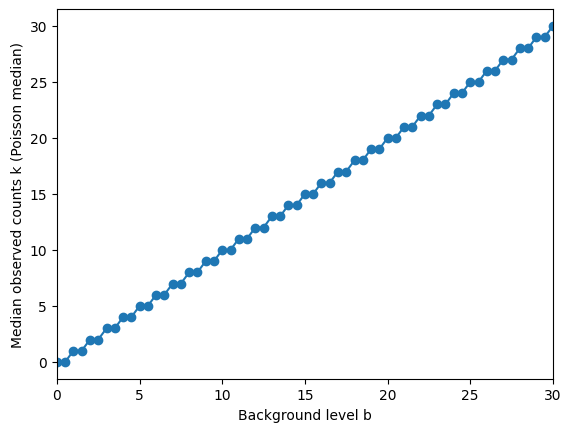

In [11]:
import time

signal_cts = np.linspace(0.,30.,300)
background_levels = np.linspace(0.,30.,61)
median_counts = poisson.ppf(0.5, background_levels)

plt.figure(1)
plt.plot(background_levels, median_counts, '-o')
plt.xlim(0.,30.)
plt.xlabel('Background level b')
plt.ylabel('Median observed counts k (Poisson median)')

critical_curves = {}

start = time.time()
for b in background_levels:
    if b % 5 == 0:
        # Print progress with elapsed time
        elapsed = time.time() - start
        print("Computing critical PLR curve for b={:.2f}, elapsed time: {:.2f} seconds".format(b, elapsed))        
        # print("Computing critical PLR curve for b={:.2f}".format(b))
    critical_curves[b] = compute_critical_plr(b, signal_cts)
    
    


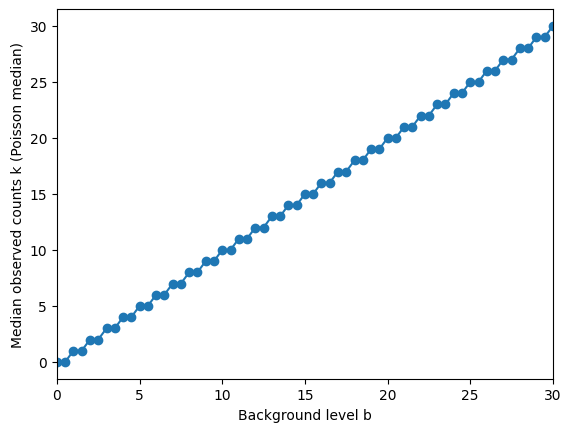

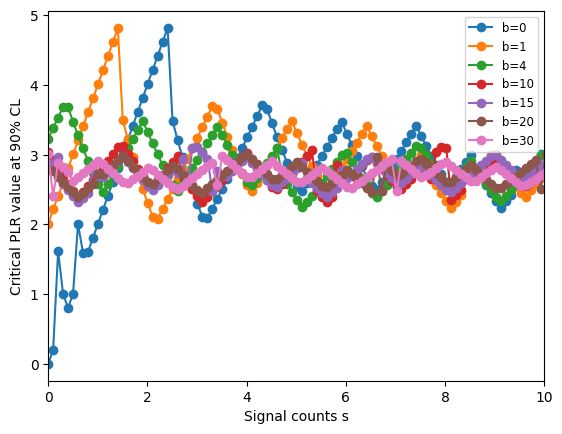

In [12]:
plt.figure(1)
plt.plot(background_levels, median_counts, '-o')
plt.xlim(0.,30.)
plt.xlabel('Background level b')
plt.ylabel('Median observed counts k (Poisson median)')

plt.figure(2)
bkgs_to_plot = [0., 1., 4., 10., 15., 20., 30.]
for b in bkgs_to_plot:
    plt.plot(signal_cts, critical_curves[b], '-o', label='b={:.0f}'.format(b))
plt.xlabel('Signal counts s')
plt.ylabel('Critical PLR value at 90% CL')
plt.xlim(0.,10.)
plt.legend(fontsize='small')

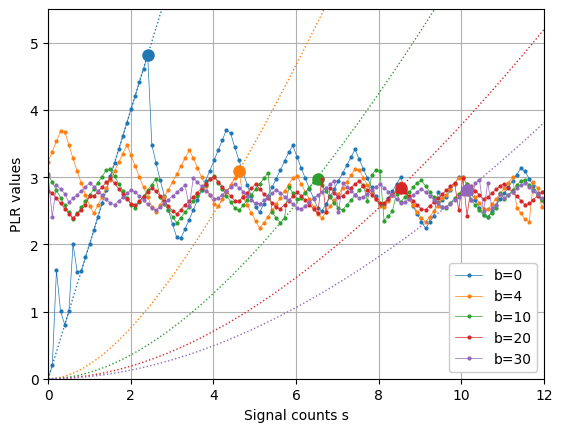

In [28]:
median_plr_curves = {}
crossing_points = {}

# Compute the actual PLR curves for each background level
for i,b in enumerate(background_levels):
    median_plr_curves[b] = plr_values = plr_stat(signal_cts, b, median_counts[i])
    # Compute the crossing point. Provide a 0.1 margin to avoid issues with numerical precision
    diffs = median_plr_curves[b] - critical_curves[b]
    crossing_indices = np.where(diffs >= 0.1)[0]
    if len(crossing_indices) > 0:
        crossing_point = signal_cts[crossing_indices[0]-1]
    else:
        crossing_point = np.nan
    crossing_points[b] = crossing_point
        
        
    
plt.figure(1)
color_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

bkgs_to_plot = [0., 4., 10., 20., 30.]
for i, b in enumerate(bkgs_to_plot):
    plt.plot(signal_cts, critical_curves[b], \
        '-o', markersize=2, linewidth=.5, label='b={:.0f}'.format(b), color=color_cycle[i])
    plt.plot(signal_cts, median_plr_curves[b], \
        ':', linewidth=1, color=color_cycle[i])
    plt.plot(crossing_points[b], critical_curves[b][np.where(signal_cts == crossing_points[b])[0][0]], \
        'o', markersize=8, color=color_cycle[i])
    
    
plt.xlabel('Signal counts s')
plt.ylabel('PLR values')
plt.xlim(0.,12.)
plt.ylim(0.,5.5)
plt.legend(framealpha=1, fontsize=10)
plt.grid()
    
    

C:\Users\bglen\AppData\Local\Temp\ipykernel_4784\1737656857.py:17: RuntimeWarning: divide by zero encountered in divide
  plt.plot(background_levels, (UL_gammaincc / xlzd_statistic(background_levels)), '-o', label='Poisson UL / XLZD UL')
C:\Users\bglen\AppData\Local\Temp\ipykernel_4784\1737656857.py:18: RuntimeWarning: divide by zero encountered in divide
  plt.plot(background_levels, (np.array(list(crossing_points.values())) / xlzd_statistic(background_levels)), '-o', label='FC UL / XLZD UL')


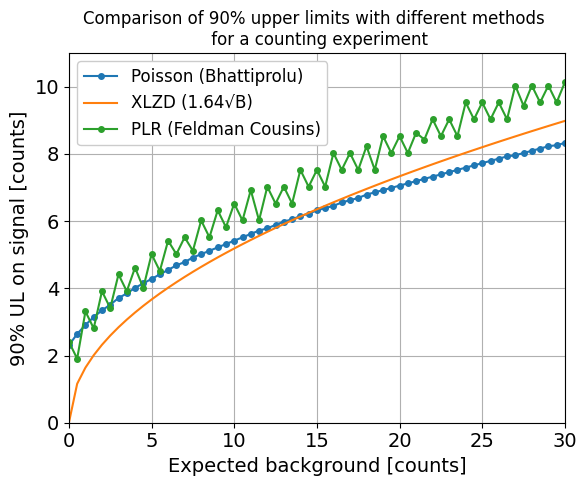

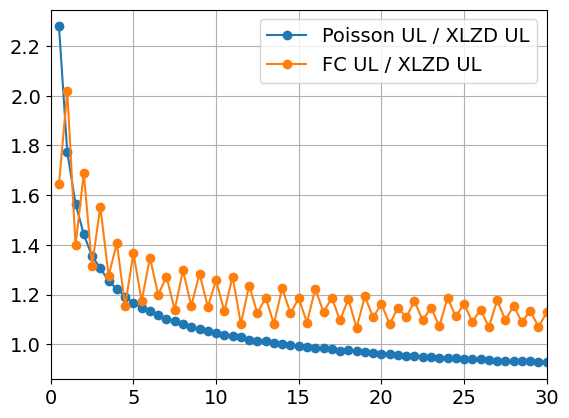

In [42]:
plt.rcParams['font.size'] = 14

UL_gammaincc = poisson_ul_gammaincc(background_levels)

plt.plot(background_levels, UL_gammaincc, '-o', markersize=4, label='Poisson (Bhattiprolu)')
plt.plot(background_levels, xlzd_statistic(background_levels), '-', label='XLZD (1.64√B)')
plt.plot(background_levels, crossing_points.values(), '-o',markersize=4, label='PLR (Feldman Cousins)')
plt.xlim(0.,30.)
plt.ylim(0.,11.)
plt.xlabel('Expected background [counts]')
plt.ylabel('90% UL on signal [counts]')
plt.legend(fontsize=12, framealpha=1)
plt.grid()
plt.title('Comparison of 90% upper limits with different methods \n for a counting experiment', fontsize=12)

plt.figure(2)
plt.plot(background_levels, (UL_gammaincc / xlzd_statistic(background_levels)), '-o', label='Poisson UL / XLZD UL')
plt.plot(background_levels, (np.array(list(crossing_points.values())) / xlzd_statistic(background_levels)), '-o', label='FC UL / XLZD UL')

plt.xlim(0.,30.)
plt.legend()

plt.grid()